### PILLARS INCLUDED

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import random
import cv2

# Constants
BACKGROUND_VAL = 0
WALL_VAL = 1
WINDOW_VAL = 2
DOOR_VAL = 3

def to_pixel_coords(x, y, scale=100, image_height=None):
    px = int(x * scale)
    py = int((image_height - y * scale))  # flip y
    return px, py

def draw_window(ax, x, y, w, h, mask, scale):
    margin = 0.1
    win_w = w * random.uniform(0.5, 0.8)
    win_h = h * random.uniform(0.5, 0.8)
    win_x = x + (w - win_w) / 2
    win_y = y + (h - win_h) / 2

    win_patch = patches.Rectangle((win_x, win_y), win_w, win_h,
                                  linewidth=2, edgecolor='black', facecolor='white')
    ax.add_patch(win_patch)

    # 50% chance for horizontal flip only
    mirror_h = random.random() < 0.5

    # Define base points
    bl = (win_x, win_y)  # bottom-left
    tm = (win_x + win_w / 2, win_y + win_h)  # top-middle
    br = (win_x + win_w, win_y)  # bottom-right
    lm = (win_x, win_y + win_h / 2)  # left-middle
    tr = (win_x + win_w, win_y + win_h)  # top-right

    # Apply horizontal mirroring if needed
    def mirror_point(xp, yp):
        if mirror_h:
            xp = win_x + win_w - (xp - win_x)
        return xp, yp

    points = [
        (bl, tm),
        (tm, br),
        (br, lm),
        (lm, tr)
    ]

    for (p1, p2) in points:
        m1 = mirror_point(*p1)
        m2 = mirror_point(*p2)
        ax.plot([m1[0], m2[0]], [m1[1], m2[1]], color='black', linewidth=1, linestyle=(0, (3, 3)))

    # Draw to mask
    px, py = to_pixel_coords(win_x, win_y, scale, mask.shape[0])
    pw, ph = int(win_w * scale), int(win_h * scale)
    cv2.rectangle(mask, (px, py - ph), (px + pw, py), WINDOW_VAL, thickness=-1)

    return (win_x, win_y, win_w, win_h)

def draw_door(ax, x, y, w, h, mask, scale):
    door_w = 0.8
    door_h = 1.6
    door_x = x + (w - door_w) / 2
    door_y = y

    door_patch = patches.Rectangle((door_x, door_y), door_w, door_h,
                                   linewidth=2, edgecolor='black', facecolor='gray')
    ax.add_patch(door_patch)

    px, py = to_pixel_coords(door_x, door_y, scale, mask.shape[0])
    pw, ph = int(door_w * scale), int(door_h * scale)
    cv2.rectangle(mask, (px, py - ph), (px + pw, py), DOOR_VAL, thickness=-1)

    return (door_x, door_y, door_w, door_h)

def draw_wall_mask(mask, x, y, w, h, scale):
    px, py = to_pixel_coords(x, y, scale, mask.shape[0])
    pw, ph = int(w * scale), int(h * scale)
    cv2.rectangle(mask, (px, py - ph), (px + pw, py), WALL_VAL, thickness=-1)

def draw_wall_pattern(ax, x, y, w, h, exclude_boxes=[]):
    for i in np.linspace(x + 0.1, x + w - 0.1, num=12):
        line_y0 = y + 0.05
        line_y1 = y + h - 0.05

        for ex_x, ex_y, ex_w, ex_h in exclude_boxes:
            if ex_x <= i <= ex_x + ex_w:
                if ex_y > line_y0:
                    ax.plot([i, i], [line_y0, ex_y], color='steelblue', linewidth=0.5)
                if ex_y + ex_h < line_y1:
                    ax.plot([i, i], [ex_y + ex_h, line_y1], color='steelblue', linewidth=0.5)
                break
        else:
            ax.plot([i, i], [line_y0, line_y1], color='steelblue', linewidth=0.5)

def draw_pillar(ax, x, y, w, h, side='left', mask=None, scale=100):
    pillar_w = 0.15 * w
    pillar_x = x if side == 'left' else x + w - pillar_w
    pillar_y = y

    pillar_patch = patches.Rectangle((pillar_x, pillar_y), pillar_w, h,
                                     linewidth=1.5, edgecolor='black', facecolor='white')
    ax.add_patch(pillar_patch)

    # Draw to mask
    px, py = to_pixel_coords(pillar_x, pillar_y, scale, mask.shape[0])
    pw, ph = int(pillar_w * scale), int(h * scale)
    cv2.rectangle(mask, (px, py - ph), (px + pw, py), WALL_VAL, thickness=-1)

    return (pillar_x, pillar_y, pillar_w, h)

def draw_pillar(ax, x, y, w, h, side='left', mask=None, scale=100):
    pillar_w = 0.15 * w
    pillar_x = x if side == 'left' else x + w - pillar_w
    pillar_y = y

    pillar_patch = patches.Rectangle((pillar_x, pillar_y), pillar_w, h,
                                     linewidth=1.5, edgecolor='black', facecolor='white')
    ax.add_patch(pillar_patch)

    # Draw to mask
    px, py = to_pixel_coords(pillar_x, pillar_y, scale, mask.shape[0])
    pw, ph = int(pillar_w * scale), int(h * scale)
    cv2.rectangle(mask, (px, py - ph), (px + pw, py), WALL_VAL, thickness=-1)

    return (pillar_x, pillar_y, pillar_w, h)

def draw_module(ax, x, y, w, h, is_door=False, draw_window_chance=0.4, mask=None, scale=100):
    ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='black', facecolor='none'))
    draw_wall_mask(mask, x, y, w, h, scale)

    exclude_boxes = []

    # Random pillar with 10% chance
    if random.random() < 0.1:
        side = random.choice(['left', 'right'])
        pillar_box = draw_pillar(ax, x, y, w, h, side=side, mask=mask, scale=scale)
        exclude_boxes.append(pillar_box)

    if is_door:
        door_box = draw_door(ax, x, y, w, h, mask, scale)
        exclude_boxes.append(door_box)
    elif random.random() < draw_window_chance:
        win_box = draw_window(ax, x, y, w, h, mask, scale)
        exclude_boxes.append(win_box)

    draw_wall_pattern(ax, x, y, w, h, exclude_boxes)

def generate_facade_structure(scale=100, save_dir="output", index=0, missing_corner_prob=0.15):
    cols = random.randint(1, 4)
    rows = random.randint(1, 4)
    module_width = 2
    module_height = 2

    total_width = cols * module_width
    total_height = rows * module_height
    image_width = int(total_width * scale)
    image_height = int(total_height * scale)

    mask = np.zeros((image_height, image_width), dtype=np.uint8)

    # Setup figure
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal')
    ax.axis('off')

    door_col = random.randint(0, cols - 1)

    for row in range(rows):
        for col in range(cols):
            # Check if this module is an outer corner
            is_top = (row == rows - 1)
            is_bottom = (row == 0)
            is_left = (col == 0)
            is_right = (col == cols - 1)

            is_outer_corner = (is_top or is_bottom) and (is_left or is_right)

            # Randomly skip outer corners based on probability
            if is_outer_corner and random.random() < missing_corner_prob:
                # Skip drawing this module (make a "hole")
                continue

            x = col * module_width
            y = row * module_height
            is_door = is_bottom and (col == door_col)

            draw_module(ax, x, y, module_width, module_height, is_door=is_door, mask=mask, scale=scale)

    ax.set_xlim(-1, total_width + 1)
    ax.set_ylim(-1, total_height + 1)
    ax.set_title("Random Facade", fontsize=16)

    # Save directory setup
    os.makedirs(save_dir, exist_ok=True)
    facade_path = os.path.join(save_dir, f"facade_{index}.png")
    mask_path = os.path.join(save_dir, f"mask_{index}.png")

    # Save facade
    fig.savefig(facade_path, bbox_inches='tight', pad_inches=0, dpi=150)
    plt.close(fig)

    # Save mask
    cv2.imwrite(mask_path, mask)

    return mask, facade_path, mask_path

# Example usage
mask, facade_file, mask_file = generate_facade_structure(index=0)
print("Saved to:", facade_file, "and", mask_file)

# Display both images
facade_img = cv2.imread(facade_file)
mask_img = cv2.imread(mask_file)

# Convert BGR (OpenCV) to RGB (matplotlib)
facade_img = cv2.cvtColor(facade_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Facade")
plt.imshow(facade_img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### PILLARS EXCLUDED

Saved to: output\facade_0.png and output\mask_0.png


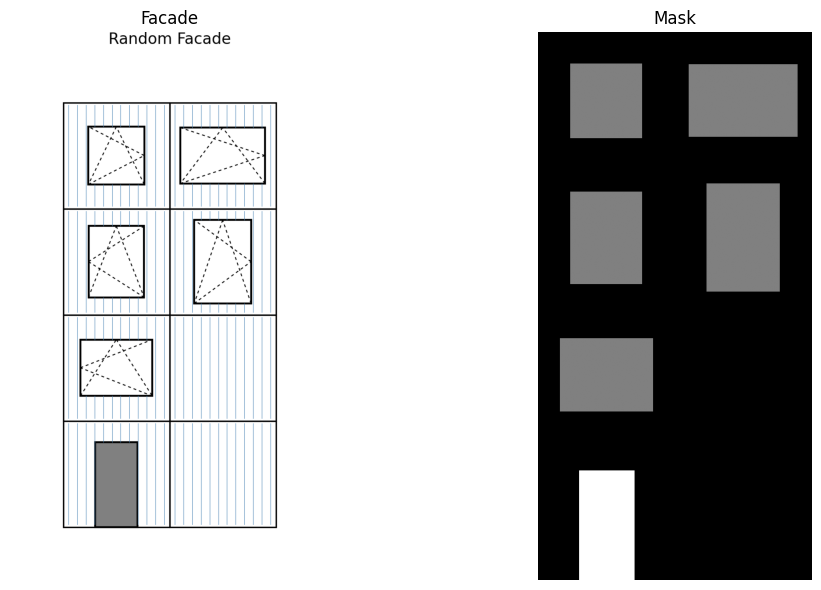

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import random
import cv2

# Constants
BACKGROUND_VAL = 0
WALL_VAL = 1
WINDOW_VAL = 2
DOOR_VAL = 3

def to_pixel_coords(x, y, scale=100, image_height=None):
    px = int(x * scale)
    py = int((image_height - y * scale))  # flip y
    return px, py

def draw_window(ax, x, y, w, h, mask, scale):
    margin = 0.1
    win_w = w * random.uniform(0.5, 0.8)
    win_h = h * random.uniform(0.5, 0.8)
    win_x = x + (w - win_w) / 2
    win_y = y + (h - win_h) / 2

    win_patch = patches.Rectangle((win_x, win_y), win_w, win_h,
                                  linewidth=2, edgecolor='black', facecolor='white')
    ax.add_patch(win_patch)

    # 50% chance for horizontal flip only
    mirror_h = random.random() < 0.5

    # Define base points
    bl = (win_x, win_y)  # bottom-left
    tm = (win_x + win_w / 2, win_y + win_h)  # top-middle
    br = (win_x + win_w, win_y)  # bottom-right
    lm = (win_x, win_y + win_h / 2)  # left-middle
    tr = (win_x + win_w, win_y + win_h)  # top-right

    # Apply horizontal mirroring if needed
    def mirror_point(xp, yp):
        if mirror_h:
            xp = win_x + win_w - (xp - win_x)
        return xp, yp

    points = [
        (bl, tm),
        (tm, br),
        (br, lm),
        (lm, tr)
    ]

    for (p1, p2) in points:
        m1 = mirror_point(*p1)
        m2 = mirror_point(*p2)
        ax.plot([m1[0], m2[0]], [m1[1], m2[1]], color='black', linewidth=1, linestyle=(0, (3, 3)))

    # Draw to mask
    px, py = to_pixel_coords(win_x, win_y, scale, mask.shape[0])
    pw, ph = int(win_w * scale), int(win_h * scale)
    cv2.rectangle(mask, (px, py - ph), (px + pw, py), WINDOW_VAL, thickness=-1)

    return (win_x, win_y, win_w, win_h)

def draw_door(ax, x, y, w, h, mask, scale):
    door_w = 0.8
    door_h = 1.6
    door_x = x + (w - door_w) / 2
    door_y = y

    door_patch = patches.Rectangle((door_x, door_y), door_w, door_h,
                                   linewidth=2, edgecolor='black', facecolor='gray')
    ax.add_patch(door_patch)

    px, py = to_pixel_coords(door_x, door_y, scale, mask.shape[0])
    pw, ph = int(door_w * scale), int(door_h * scale)
    cv2.rectangle(mask, (px, py - ph), (px + pw, py), DOOR_VAL, thickness=-1)

    return (door_x, door_y, door_w, door_h)

def draw_wall_mask(mask, x, y, w, h, scale):
    px, py = to_pixel_coords(x, y, scale, mask.shape[0])
    pw, ph = int(w * scale), int(h * scale)
    cv2.rectangle(mask, (px, py - ph), (px + pw, py), WALL_VAL, thickness=-1)

def draw_wall_pattern(ax, x, y, w, h, exclude_boxes=[]):
    for i in np.linspace(x + 0.1, x + w - 0.1, num=12):
        line_y0 = y + 0.05
        line_y1 = y + h - 0.05

        for ex_x, ex_y, ex_w, ex_h in exclude_boxes:
            if ex_x <= i <= ex_x + ex_w:
                if ex_y > line_y0:
                    ax.plot([i, i], [line_y0, ex_y], color='steelblue', linewidth=0.5)
                if ex_y + ex_h < line_y1:
                    ax.plot([i, i], [ex_y + ex_h, line_y1], color='steelblue', linewidth=0.5)
                break
        else:
            ax.plot([i, i], [line_y0, line_y1], color='steelblue', linewidth=0.5)

def draw_pillar(ax, x, y, w, h, side='left', mask=None, scale=100):
    pillar_w = 0.15 * w
    pillar_x = x if side == 'left' else x + w - pillar_w
    pillar_y = y

    pillar_patch = patches.Rectangle((pillar_x, pillar_y), pillar_w, h,
                                     linewidth=1.5, edgecolor='black', facecolor='white')
    ax.add_patch(pillar_patch)

    # Draw to mask
    px, py = to_pixel_coords(pillar_x, pillar_y, scale, mask.shape[0])
    pw, ph = int(pillar_w * scale), int(h * scale)
    cv2.rectangle(mask, (px, py - ph), (px + pw, py), WALL_VAL, thickness=-1)

    return (pillar_x, pillar_y, pillar_w, h)

def draw_module(ax, x, y, w, h, is_door=False, draw_window_chance=0.4, mask=None, scale=100):
    ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='black', facecolor='none'))
    draw_wall_mask(mask, x, y, w, h, scale)

    exclude_boxes = []

    if is_door:
        door_box = draw_door(ax, x, y, w, h, mask, scale)
        exclude_boxes.append(door_box)
    elif random.random() < draw_window_chance:
        win_box = draw_window(ax, x, y, w, h, mask, scale)
        exclude_boxes.append(win_box)

    draw_wall_pattern(ax, x, y, w, h, exclude_boxes)

def generate_facade_structure(scale=100, save_dir="output", index=0, missing_corner_prob=0.15):
    cols = random.randint(1, 4)
    rows = random.randint(1, 4)
    module_width = 2
    module_height = 2

    total_width = cols * module_width
    total_height = rows * module_height
    image_width = int(total_width * scale)
    image_height = int(total_height * scale)

    mask = np.zeros((image_height, image_width), dtype=np.uint8)

    # Setup figure
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal')
    ax.axis('off')

    door_col = random.randint(0, cols - 1)

    for row in range(rows):
        for col in range(cols):
            # Check if this module is an outer corner
            is_top = (row == rows - 1)
            is_bottom = (row == 0)
            is_left = (col == 0)
            is_right = (col == cols - 1)

            is_outer_corner = (is_top or is_bottom) and (is_left or is_right)

            # Randomly skip outer corners based on probability
            if is_outer_corner and random.random() < missing_corner_prob:
                # Skip drawing this module (make a "hole")
                continue

            x = col * module_width
            y = row * module_height
            is_door = is_bottom and (col == door_col)

            draw_module(ax, x, y, module_width, module_height, is_door=is_door, mask=mask, scale=scale)

    ax.set_xlim(-1, total_width + 1)
    ax.set_ylim(-1, total_height + 1)
    ax.set_title("Random Facade", fontsize=16)

    # Save directory setup
    os.makedirs(save_dir, exist_ok=True)
    facade_path = os.path.join(save_dir, f"facade_{index}.png")
    mask_path = os.path.join(save_dir, f"mask_{index}.png")

    # Save facade
    fig.savefig(facade_path, bbox_inches='tight', pad_inches=0, dpi=150)
    plt.close(fig)

    # Save mask
    cv2.imwrite(mask_path, mask)

    return mask, facade_path, mask_path

# Example usage
mask, facade_file, mask_file = generate_facade_structure(index=0)
print("Saved to:", facade_file, "and", mask_file)

# Display both images
facade_img = cv2.imread(facade_file)
mask_img = cv2.imread(mask_file)

# Convert BGR (OpenCV) to RGB (matplotlib)
facade_img = cv2.cvtColor(facade_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Facade")
plt.imshow(facade_img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import hashlib

def hash_mask(mask):
    return hashlib.sha256(mask.tobytes()).hexdigest() # Convert the mask to a hash to efficiently compare duplicates.

def generate_multiple_facades(num_facades=10, scale=100, save_dir="generated_facades", allow_duplicates=False):
    os.makedirs(save_dir, exist_ok=True)
    seen_hashes = set()
    results = []
    saved_count = 0
    attempts = 0
    max_attempts = num_facades * 5  # safety cap

    while saved_count < num_facades and attempts < max_attempts:
        mask, facade_path, mask_path = generate_facade_structure(scale=scale, save_dir=save_dir, index=saved_count)
        mask_hash = hash_mask(mask)
        attempts += 1

        if not allow_duplicates and mask_hash in seen_hashes:
            print(f"Duplicate detected. Skipping facade {saved_count}")
            continue

        seen_hashes.add(mask_hash)
        results.append((mask, facade_path, mask_path))
        print(f"Saved facade {saved_count} to: {facade_path} and mask to: {mask_path}")
        saved_count += 1

    if saved_count < num_facades:
        print(f"Warning: Only generated {saved_count} unique facades out of {num_facades} after {attempts} attempts.")

    return results

In [4]:
generate_multiple_facades(num_facades=500, allow_duplicates=False)

Saved facade 0 to: generated_facades\facade_100.png and mask to: generated_facades\mask_100.png
Saved facade 1 to: generated_facades\facade_101.png and mask to: generated_facades\mask_101.png
Saved facade 2 to: generated_facades\facade_102.png and mask to: generated_facades\mask_102.png
Saved facade 3 to: generated_facades\facade_103.png and mask to: generated_facades\mask_103.png
Saved facade 4 to: generated_facades\facade_104.png and mask to: generated_facades\mask_104.png
Saved facade 5 to: generated_facades\facade_105.png and mask to: generated_facades\mask_105.png
Saved facade 6 to: generated_facades\facade_106.png and mask to: generated_facades\mask_106.png
Saved facade 7 to: generated_facades\facade_107.png and mask to: generated_facades\mask_107.png
Saved facade 8 to: generated_facades\facade_108.png and mask to: generated_facades\mask_108.png
Saved facade 9 to: generated_facades\facade_109.png and mask to: generated_facades\mask_109.png
Saved facade 10 to: generated_facades\fa

[(array([[1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'generated_facades\\facade_100.png',
  'generated_facades\\mask_100.png'),
 (array([[1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         ...,
         [1, 1, 1, ..., 0, 0, 0],
         [1, 1, 1, ..., 0, 0, 0],
         [1, 1, 1, ..., 0, 0, 0]], dtype=uint8),
  'generated_facades\\facade_101.png',
  'generated_facades\\mask_101.png'),
 (array([[1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         ...,
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1]], dtype=uint8),
  'generated_facades\\facade_102.png',
  'generated_facades\\mask_102.png'),
 (array([[1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
  

In [ ]:
# wall_pixels = np.sum(mask == WALL_VAL)
# pixel_area = (1 / 100) ** 2  # e.g., if scale=100, pixel = 0.01 x 0.01
# wall_area = wall_pixels * pixel_area

In [ ]:
# wall_area

41.754000000000005